<a href="https://colab.research.google.com/github/richab2005/MachineLearning-/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Step 1: Import libraries
import pandas as pd

# Step 2: Load dataset (Pima Indians Diabetes)
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# Step 3: Display basic info
print(df.shape)
print(df.head())


(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [4]:
y=df[['Outcome']]
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2)

In [6]:
print("Shape of x_train", x_train.shape)
print("Shape of y_train", y_train.shape)
print("Shape of x_test", x_test.shape)
print("Shape of y_test", y_test.shape)

Shape of x_train (614, 8)
Shape of y_train (614, 1)
Shape of x_test (154, 8)
Shape of y_test (154, 1)


In [7]:
from sklearn.linear_model import LogisticRegression
logRegressor= LogisticRegression(random_state= 16)
logRegressor.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=16)

In [8]:
y_pred= logRegressor.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0])

In [9]:
print("Shape of y_pred", y_pred.shape)

Shape of y_pred (154,)


In [10]:
from sklearn.metrics import confusion_matrix
cnfmat= confusion_matrix(y_test, y_pred)
print(cnfmat)

[[97 12]
 [20 25]]


In [11]:
TN, TP, FP, FN= cnfmat.ravel()
print(f"True Positives (TP): {TP}")
print(f"True Negative (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negative (FN): {FN}")

True Positives (TP): 12
True Negative (TN): 97
False Positives (FP): 20
False Negative (FN): 25


In [12]:
from sklearn import metrics

accuracy= metrics.accuracy_score(y_test, y_pred)
print("Accuracy using in-built function= ", accuracy*100)

acc= (TP+TN)/(TP+TN+FP+FN)
print("Accuracy using manually calculated formula= ", acc*100)

acc1= acc*100
acc1_round= round(acc1, 2)
print("Accuracy using manually calculated formula rounded to two decimals= ", acc1_round)

rec= metrics.recall_score(y_test, y_pred)
print("\nRecall using in-built function= ", rec*100)

rec1= TP/(FN+TP)
print("Recall using manually calculated formula= ", rec1*100)

pre= metrics.precision_score(y_test, y_pred)
print("\nPrecision Score using in-built function= ", pre*100)

pre1= TP/(FP+TP)
print("Precision Score manually calculated formula= ", pre1*100)

f1= metrics.f1_score(y_test, y_pred)
print("\nF1 Score using in-built function= ", f1*100)

f1_formula=(2* pre *rec)/(pre+rec)
print("F1 Score manually calculated formula= ", f1_formula*100)

Accuracy using in-built function=  79.22077922077922
Accuracy using manually calculated formula=  70.77922077922078
Accuracy using manually calculated formula rounded to two decimals=  70.78

Recall using in-built function=  55.55555555555556
Recall using manually calculated formula=  32.432432432432435

Precision Score using in-built function=  67.56756756756756
Precision Score manually calculated formula=  37.5

F1 Score using in-built function=  60.97560975609756
F1 Score manually calculated formula=  60.97560975609757


In [13]:
from sklearn.metrics import confusion_matrix

In [14]:
data4= df['Outcome'].unique()
data4

array([1, 0])

In [15]:
data5= df['Outcome'].value_counts()

In [16]:
data5

,count
Outcome,
0,500
1,268


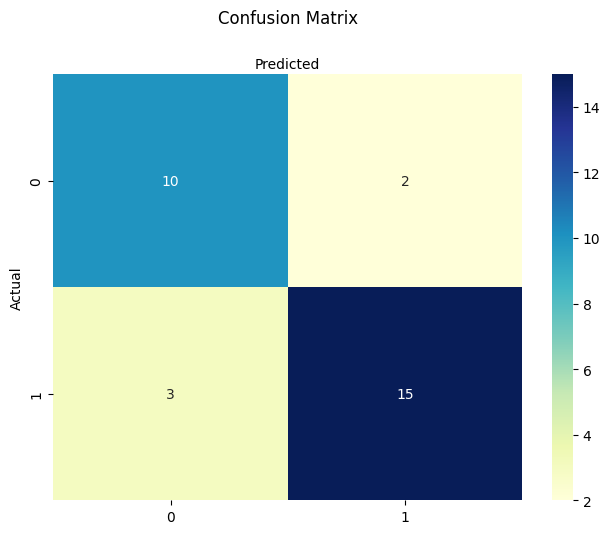

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# You must define cfmat and class_names
# Example definitions:
cfmat = [[10, 2], [3, 15]]
class_names = ['Class 0', 'Class 1']

fig, ax= plt.subplots()
tick_marks= np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cfmat), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title("Confusion Matrix", y=1.1)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show() # Add this line to display the plot

<Axes: xlabel='Age', ylabel='Outcome'>

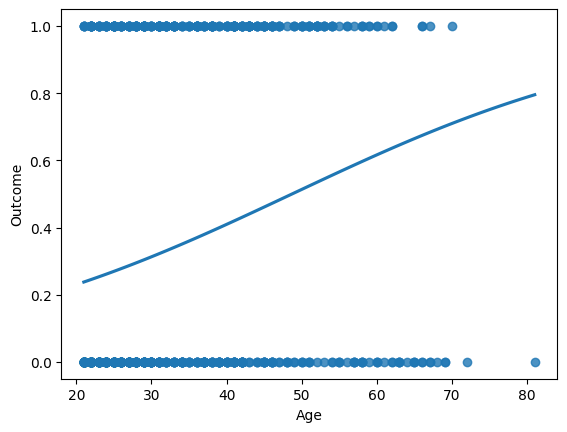

In [18]:
x1= df['Age']
y1=df['Outcome']
sns.regplot(x=x1, y=y1, data=df, logistic=True, ci=None)